In [10]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from aniposelib.cameras import CameraGroup
from tqdm import tqdm

from lightning_pose.utils.io import fix_empty_first_row

In [ ]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

# DATASET_NAME = "fly-anipose"
# DATASET_NAME = "chickadee-crop"
# DATASET_NAME = "mirror-mouse-separate"
DATASET_NAME = "ibl-mouse"
DATA_DIR = f"/teamspace/studios/data/{DATASET_NAME}"
BASE_DIR = f"/teamspace/studios/this_studio/outputs/{DATASET_NAME}"


# Path to the calibration mapping file
CALIB_MAP_FILE = os.path.join(DATA_DIR, "calibrations_new.csv")

# Map "Display Name" -> "Directory Name"
MODELS = {
    "SVT": "test_200_SV_vits_dino",
    "MVT": "test_200_MVT_dlc",
    
    # "MVT_3d_aug": "test_200_MVT_3d_aug",
    # "MVT_3d_loss": "test_200_MVT_3d_loss_(0_3)",
    # "MVT_patch_masking": "test_200_MVT_patch_masking_no3d_loss",
    "MVT_patch_masking": "test_200_MVT_patch_masking",
    # "MVT++": "test_200_MVT_3d_loss_patch_masking",

}

# Dataset specific view names (Ensure these match your dataset)
# Example for fly: ["Cam-A", "Cam-B", "Cam-C", "Cam-D", "Cam-E", "Cam-F"]
# Example for chickadee: ['lBack', 'lFront', 'lTop', 'rBack', 'rFront', 'rTop']
# Example for mouse: ['top', 'bot']
# VIEWS = ['top', 'bot']  # UPDATE THIS for your current dataset!
# VIEWS = ["Cam-A", "Cam-B", "Cam-C", "Cam-D", "Cam-E", "Cam-F"]
# VIEWS = ["lBack", "lFront", "lTop", "rBack", "rFront", "rTop"]
VIEWS = ['top', 'bot']

# MODELS = ["SVT", "MVT", "MVT++"]
SEEDS = [0, 1, 2]

model_colors = {
    "SVT": "lightseagreen",
    "MVT": "pink", 
    "MVT_3d_aug": "pink", # Optional if in your list
    "MVT_3d_loss": "green",
    "MVT_patch_masking": "orange", # Optional if in your list
    "MVT++": "purple"
}

In [12]:
# -----------------------------------------------------------------------------
# Helper Functions
# -----------------------------------------------------------------------------

def find_seed_dirs(model_path):
    """
    Finds subdirectories ending in _0, _1, _2, etc. inside the model path.
    """
    model_path = Path(model_path)
    if not model_path.exists():
        print(f"  Warning: Path not found: {model_path}")
        return []
        
    # Look for directories matching pattern *_{seed} where seed is 0-9
    # Common patterns: supervised_200_0, multiview_transformer_200_0, mvt_3d_loss_200_0
    seed_dirs = []
    for item in model_path.iterdir():
        if item.is_dir():
            # Check if it ends with _digit
            parts = item.name.split('_')
            if parts[-1].isdigit():
                seed_dirs.append(item)
                
    return sorted(seed_dirs)

In [13]:
# ... (Configuration section)
# DATASET_NAME = "chickadee-crop"
# VIEWS = ['lBack', 'lFront', 'lTop', 'rBack', 'rFront', 'rTop'] # Update this!

def load_pixel_errors(seed_dir, views):
    errors = []
    found_files = []
    
    # Iterate through expected views to find specific files
    for view in views:
        # Construct expected filename pattern
        # Typically: predictions_{view}_new_pixel_error.csv
        # It might be in the root of seed_dir or in a subdir.
        
        filename = f"predictions_{view}_new_pixel_error.csv"
        
        # Search for this specific file recursively
        found = list(seed_dir.glob(f"**/{filename}"))
        
        if not found:
            # Try alternative naming just in case? e.g. predictions_{view}_pixel_error.csv
            # print(f"    Warning: Missing predictions for view {view}")
            continue
            
        # If multiple found (duplicates in subdirs), pick the one that seems most relevant?
        # Usually the shortest path (root) or 'image_preds' is correct.
        # Let's just pick the first one found, but warn if duplicates.
        
        target_file = found[0]
        if len(found) > 1:
            # print(f"    Warning: Multiple files found for {view}: {[f.name for f in found]}. Using {target_file}")
            pass
            
        found_files.append(target_file)
        
        try:
            df = pd.read_csv(target_file, index_col=0)
            
            # Handle 'set' column logic (test/unused)
            set_col = None
            if 'set' in df.columns:
                set_col = df['set']
            elif ('set','','') in df.columns:
                set_col = df[('set','','')]
            
            if set_col is not None:
                mask = set_col.isin(['test', 'unused'])
                if not mask.any():
                    # Fallback if 'test' set empty or missing
                    vals = df.drop(columns=['set'] if 'set' in df.columns else [('set','','')]).values.flatten()
                else:
                    df_filtered = df[mask]
                    cols_to_drop = ['set'] if 'set' in df_filtered.columns else [('set','','')]
                    vals = df_filtered.drop(columns=cols_to_drop).values.flatten()
            else:
                vals = df.values.flatten()
                
            vals = pd.to_numeric(vals, errors='coerce')
            vals = vals[~np.isnan(vals)]
            
            if len(vals) > 0:
                errors.extend(vals)
                
        except Exception as e:
            print(f"    Error reading {target_file.name}: {e}")

    if found_files:
        print(f"    Found {len(found_files)} files for views: {[f.name.replace('predictions_','').replace('_new_pixel_error.csv','') for f in found_files]}")
    else:
        print(f"    No files found matching view patterns.")
        
    return np.array(errors)

# ... (Update main loop to pass VIEWS)
# errors = load_pixel_errors(s_dir, VIEWS)

In [14]:
# -----------------------------------------------------------------------------
# Main Collection Loop
# -----------------------------------------------------------------------------

aggregated_data = []

print(f"Processing dataset: {DATASET_NAME}")

for display_name, dir_name in MODELS.items():
    print(f"\nModel: {display_name}")
    model_full_path = os.path.join(BASE_DIR, dir_name)
    
    seed_dirs = find_seed_dirs(model_full_path)
    if not seed_dirs:
        print("  No seed directories found.")
        continue
        
    print(f"  Found {len(seed_dirs)} seeds: {[d.name for d in seed_dirs]}")
    print(f" the path is {model_full_path}")
    
    for s_dir in seed_dirs:
        # Extract seed number for record keeping
        seed_num = int(s_dir.name.split('_')[-1])
        
        errors = load_pixel_errors(s_dir,VIEWS)
        
        if len(errors) == 0:
            print(f"    No error data found in {s_dir.name}")
            continue
            
        # Add to aggregation
        # We can store every single point, or just the mean per seed if dataset is huge
        # Storing all points allows for true distribution plotting
        for e in errors:
            aggregated_data.append({
                "Model": display_name,
                "Seed": seed_num,
                "Pixel Error": e
            })
            
    print(f"  Collected data for {display_name}")


Processing dataset: mirror-mouse-separate

Model: SVT
  Found 3 seeds: ['supervised_200_0', 'supervised_200_1', 'supervised_200_2']
 the path is /teamspace/studios/this_studio/outputs/mirror-mouse-separate/test_200_SV_vits_dino
    Found 2 files for views: ['top', 'bot']
    Found 2 files for views: ['top', 'bot']
    Found 2 files for views: ['top', 'bot']
  Collected data for SVT

Model: MVT
  Found 3 seeds: ['multiview_transformer_200_0', 'multiview_transformer_200_1', 'multiview_transformer_200_2']
 the path is /teamspace/studios/this_studio/outputs/mirror-mouse-separate/test_200_MVT_dlc
    Found 2 files for views: ['top', 'bot']
    Found 2 files for views: ['top', 'bot']
    Found 2 files for views: ['top', 'bot']
  Collected data for MVT

Model: MVT_patch_masking
  Found 3 seeds: ['multiview_transformer_200_0', 'multiview_transformer_200_1', 'multiview_transformer_200_2']
 the path is /teamspace/studios/this_studio/outputs/mirror-mouse-separate/test_200_MVT_patch_masking
    Fo

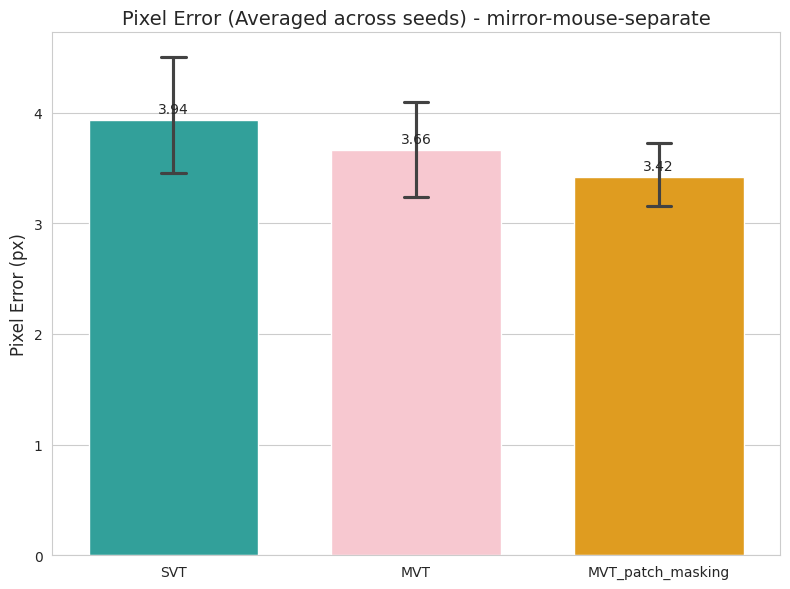


Summary Stats:
                    count      mean        std
Model                                         
MVT                1657.0  3.662615   9.250150
MVT_patch_masking  1657.0  3.420166   5.961798
SVT                1657.0  3.936781  11.035631


In [15]:
# -----------------------------------------------------------------------------
# Plotting
# -----------------------------------------------------------------------------

if aggregated_data:
    df_plot = pd.DataFrame(aggregated_data)
    
    # Filter huge outliers for visualization if needed (optional)
    # df_plot = df_plot[df_plot["Pixel Error"] < 50] 
    
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))
    
    ax = sns.barplot(
        data=df_plot,
        x="Model",
        y="Pixel Error",
        hue="Model",
        palette=model_colors,
        errorbar=('ci', 95), # 95% confidence interval
        capsize=0.1,
        width=0.7,
        dodge=False
    )
    
    plt.title(f"Pixel Error (Averaged across seeds) - {DATASET_NAME}", fontsize=14)
    plt.ylabel("Pixel Error (px)", fontsize=12)
    plt.xlabel("")
    
    # Add labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)
        
    plt.tight_layout()
    plt.show()
    
    print("\nSummary Stats:")
    print(df_plot.groupby("Model")["Pixel Error"].describe()[['count', 'mean', 'std']])
else:
    print("No data found to plot.")